# Landmine HSI — Burial-Depth Detectability (LOCAL / VS Code / GPU)
### UAV VNIR Hyperspectral · RIT-DIRS dataset · RTX 5070 Laptop (Blackwell)

Runs entirely on your laptop. GPU acceleration via **CuPy** (drop-in NumPy on CUDA) — no PyTorch
needed, which avoids the Blackwell/sm_120 support gap. Falls back to NumPy automatically if the GPU
isn't ready, so the notebook always runs.

**Wired to the real files (verified):**
- `elm_corrected_vnir` (+`.hdr`) — 6631×3123×272, float32, **BSQ**, Geographic Lat/Lon (WGS-84), reflectance **0–100 scale**
- `EO_properties_and_Locations_field2.csv` — 150 targets; **Depth (cm)**, Ferrous flag, lon/lat (two 'ID' columns → de-duplicated)
- `Spectral_Signatures_of_Targets/*.sig` — **2-column** (Wavelength(nm), Reflectance) on a **0–1 scale** → ×100 to match cube
- `SVC_...calibration_panels.csv`, `GCP_points.csv`

> ⚠️ Confirm the dataset license before publishing derived results.


## 0 · One-time environment (run in a terminal, NOT this cell)

See the setup guide for details. Summary:
```bash
conda create -n mines python=3.11 -y
conda activate mines
pip install numpy scipy scikit-learn pandas matplotlib spectral rasterio tqdm ipykernel
# GPU (Blackwell needs CUDA 12.8+ wheels):
pip install cupy-cuda12x
```
Then select the `mines` kernel in VS Code (top-right of the notebook).

## 1 · Imports + GPU backend selection

In [1]:
import os, glob, time, numpy as np, pandas as pd, matplotlib.pyplot as plt
import spectral
from scipy.ndimage import binary_dilation
from sklearn.metrics import (roc_curve, roc_auc_score,
                             precision_recall_curve, average_precision_score)

# --- GPU backend: use CuPy if available & working, else NumPy ---
USE_GPU = True
xp = np
gpu_ok = False
if USE_GPU:
    try:
        import cupy as cp
        cp.zeros(1)+1          # smoke test — will raise if the CUDA build can't run on this GPU
        xp = cp; gpu_ok = True
        print("GPU backend: CuPy on", cp.cuda.runtime.getDeviceProperties(0)['name'].decode())
    except Exception as e:
        print("CuPy unavailable/incompatible -> using NumPy CPU. Reason:", str(e)[:120])
if not gpu_ok:
    print("CPU backend: NumPy")

def to_xp(a):  return xp.asarray(a)
def to_np(a):  return cp.asnumpy(a) if gpu_ok else np.asarray(a)
np.set_printoptions(precision=3, suppress=True); plt.rcParams['figure.dpi']=110

C:\Users\sabah\.conda\envs\mines\Lib\site-packages\cupy\_environment.py:284: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


GPU backend: CuPy on NVIDIA GeForce RTX 5070 Laptop GPU


## 2 · Paths & constants (EDIT `DATA_DIR`)

Use a normal local path. On Windows, either use a raw string `r"C:\\Users\\you\\landmine_hsi"`
or forward slashes.

In [2]:
DATA_DIR = r"D:/landmine_hsi"          # <-- EDIT to your local dataset folder

CUBE_HDR  = os.path.join(DATA_DIR, "elm_corrected_vnir.hdr")
EO_CSV    = os.path.join(DATA_DIR, "EO_properties_and_Locations_field2.csv")
PANEL_CSV = os.path.join(DATA_DIR, "SVC_spectral_measurements_of_calibration_panels_in_the_scene.csv")
SIG_DIR   = os.path.join(DATA_DIR, "Spectral_Signatures_of_Targets")
FIG_DIR   = os.path.join(DATA_DIR, "figures"); os.makedirs(FIG_DIR, exist_ok=True)

# Georeferencing from .hdr map info (Geographic Lat/Lon, WGS-84)
X_TIE, Y_TIE = -96.85744848, 36.35322567
DX, DY       = 1.0e-07, 8.0e-08
SAMPLES, LINES, BANDS = 6631, 3123, 272
GOOD_BAND_MAX_NM = 900
COV_REG = 1e-3
TARGET_HALF = 1
SIG_SCALE = 100.0     # .sig reflectance is 0-1; cube is 0-100

def lonlat_to_pixel(lon, lat):
    return (Y_TIE - lat)/DY, (lon - X_TIE)/DX
print("Config set. DATA_DIR =", DATA_DIR)

Config set. DATA_DIR = D:/landmine_hsi


## 3 · Open cube memory-mapped (nothing loads into RAM yet)

In [3]:
img = spectral.open_image(CUBE_HDR)
mm  = img.open_memmap(writable=False)
WL  = np.array([float(w) for w in img.metadata['wavelength']])
band_ok = WL <= GOOD_BAND_MAX_NM
WL_use  = WL[band_ok]
print("Cube:", mm.shape, mm.dtype, "| analysis bands:", int(band_ok.sum()))

Cube: (3123, 6631, 272) float32 | analysis bands: 226


## 4 · Targets → pixels → burial/material classes

In [4]:
eo = pd.read_csv(EO_CSV, encoding='utf-8-sig')
# strip + de-dup columns (CSV has two 'ID' columns)
_c=[c.strip() for c in eo.columns]; _s={}; _dd=[]
for c in _c:
    if c in _s: _s[c]+=1; _dd.append(f"{c}.{_s[c]}")
    else: _s[c]=0; _dd.append(c)
eo.columns=_dd

# --- classify every row: real target / control hole / blank ------------------
# The CSV has 150 rows but only ~131 are real targets: 8 are CONTROL HOLES
# (empty dug reference points, no ordnance) and 11 are BLANK/placeholder rows.
# Including holes/blanks as "targets" inflated the counts and corrupted results.
def row_kind(item):
    s=str(item).strip()
    if s=='' or s.lower()=='nan': return 'blank'
    if 'hole' in s.lower():       return 'control_hole'
    return 'target'
eo['kind']=eo['Item'].apply(row_kind)

def burial_class(d):
    # NOTE: 6 cm shallow/deep cut is a modeling choice; prefer depth_cm regression.
    try: d=float(d)
    except: return None
    return 'surface' if d==0 else ('shallow' if d<=6 else 'deep')
def material_class(fe):
    s=str(fe).strip(); return 'metal' if s=='1' else ('non_metal' if s=='0' else None)
def emi_class(item, ferrous, cls):
    s=str(item).lower(); c=str(cls).lower(); fe=str(ferrous).strip()
    if fe=='1': return 'conductive'
    if any(k in s for k in ['alum','copper','brass','steel','can','pipe bomb','copper pipe',
                            'phone','htc','huawei','cooker','tipman','shell','drill','mk ']): return 'conductive'
    if '3d print' in c or any(k in s for k in
            ['pvc','tnt','plastic','pmn','pfm','ts-50','vs-1.6','vpma','ozm','propane']): return 'inert'
    if fe=='0': return 'inert'
    return 'unknown'
def num_depth(d):
    try: return float(d)
    except: return np.nan

targets=[]; holes=[]
for _,r in eo.iterrows():
    if pd.isna(r['Longitude']) or pd.isna(r['Latitude']): continue
    lon,lat=float(r['Longitude']),float(r['Latitude'])
    row,col=lonlat_to_pixel(lon,lat)
    if not(0<=row<LINES and 0<=col<SAMPLES): continue
    rec=dict(id=str(r['ID']).strip(), item=str(r['Item']).strip(),
             lon=lon, lat=lat, depth=r['Depth'], depth_cm=num_depth(r['Depth']),
             row=int(round(row)), col=int(round(col)))
    if r['kind']=='control_hole':
        holes.append(rec)                                   # kept aside as control
    elif r['kind']=='target':
        b=burial_class(r['Depth'])
        if b is None: continue
        rec.update(burial=b, material=material_class(r['Ferrous (1) or NF (0)']),
                   emi_class=emi_class(r['Item'], r['Ferrous (1) or NF (0)'], r['Class']))
        targets.append(rec)
    # blanks ignored

from collections import Counter
print("=== TARGET SET (cleaned) ===")
print(f"real targets used  : {len(targets)}   (excl. {int((eo.kind=='control_hole').sum())} holes, "
      f"{int((eo.kind=='blank').sum())} blanks)")
print("burial  :", dict(Counter(t['burial']   for t in targets)))
print("material:", dict(Counter(t['material']  for t in targets)))
print("emi_cls :", dict(Counter(t['emi_class'] for t in targets)))
print(f"control holes kept aside: {len(holes)}")

=== TARGET SET (cleaned) ===
real targets used  : 131   (excl. 8 holes, 11 blanks)
burial  : {'deep': 30, 'shallow': 70, 'surface': 31}
material: {'non_metal': 41, 'metal': 86, None: 4}
emi_cls : {'conductive': 104, 'inert': 25, 'unknown': 2}
control holes kept aside: 8


## 5 · Load the field crop once (memmap → RAM)

Field is ~1337×2808×272 float32 ≈ **4.1 GB**. That fits your 32-GB-class system RAM easily; it is
*not* loaded onto the 8 GB GPU. Only per-detector matrices go to the GPU.

In [5]:
MARGIN=60
r0=max(0,min(t['row'] for t in targets)-MARGIN); r1=min(LINES,max(t['row'] for t in targets)+MARGIN)
c0=max(0,min(t['col'] for t in targets)-MARGIN); c1=min(SAMPLES,max(t['col'] for t in targets)+MARGIN)
print(f"Crop rows[{r0}:{r1}] cols[{c0}:{c1}] -> {r1-r0}x{c1-c0}x{BANDS} (~{(r1-r0)*(c1-c0)*BANDS*4/1e9:.1f} GB)")
t0=time.time()
field=np.asarray(mm[r0:r1,c0:c1,:],dtype=np.float32)
H,W=field.shape[:2]
for t in targets: t['r']=t['row']-r0; t['c']=t['col']-c0
print(f"Loaded field {field.shape} in {time.time()-t0:.1f}s")

Crop rows[1479:2816] cols[2786:5573] -> 1337x2787x272 (~4.1 GB)
Loaded field (1337, 2787, 272) in 0.0s


## 6 · RGB preview + target map (Figure 1)

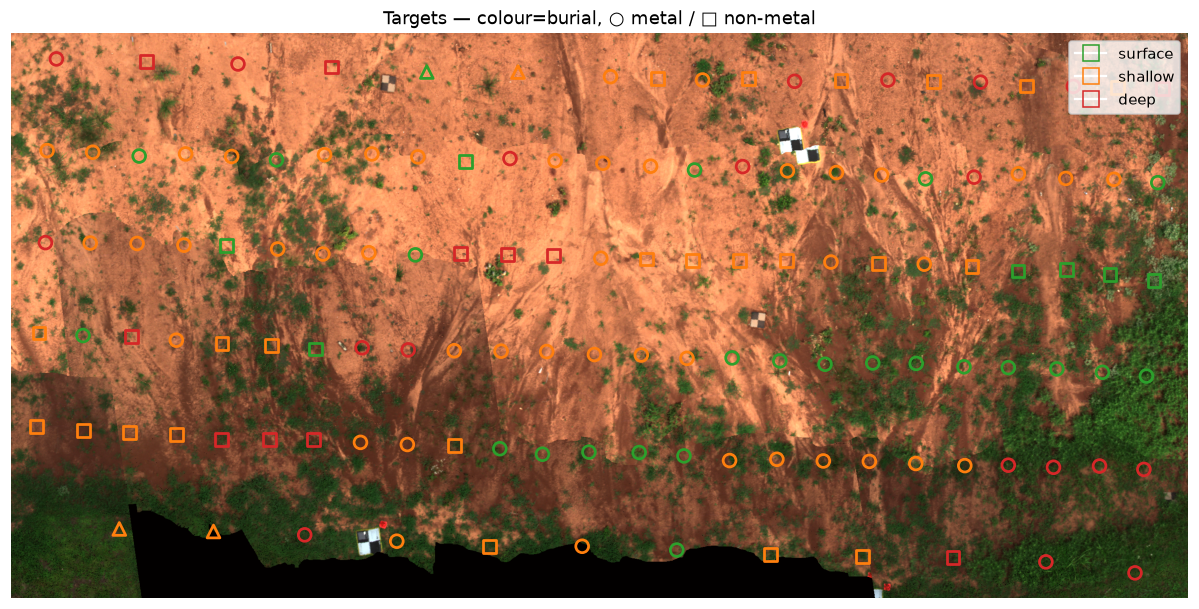

In [6]:
def rgb_of(cube):
    idx=[np.argmin(abs(WL-x)) for x in (640,550,470)]
    comp=cube[:,:,idx].astype(float); lo,hi=np.percentile(comp,[2,98])
    return np.clip((comp-lo)/(hi-lo+1e-9),0,1)
RGB=rgb_of(field)
colors={'surface':'#2ca02c','shallow':'#ff7f0e','deep':'#d62728'}
fig,ax=plt.subplots(figsize=(11,6)); ax.imshow(RGB)
for t in targets:
    m={'metal':'o','non_metal':'s'}.get(t['material'],'^')
    ax.scatter(t['c'],t['r'],s=70,facecolors='none',edgecolors=colors[t['burial']],lw=1.8,marker=m)
h=[plt.Line2D([0],[0],marker='s',color='w',markeredgecolor=c,markerfacecolor='none',markersize=10,label=b)
   for b,c in colors.items()]
ax.legend(handles=h,loc='upper right'); ax.set_title("Targets — colour=burial, ○ metal / □ non-metal")
ax.axis('off'); plt.tight_layout(); plt.savefig(f"{FIG_DIR}/fig1_target_map.png",bbox_inches='tight'); plt.show()

## 7 · Reference spectra from `.sig` (2-column, ×100)

Your `.sig` files are `Wavelength(nm)\tReflectance` with a 1-line header, wavelength 338–2515 nm,
reflectance on a **0–1** scale. We resample to the cube grid and ×100 to match the 0–100 cube.

Some targets (e.g. A9) have **several** `.sig` measurements (clean vs metal vs dirt-area). We index every file by its leading ID, rank them (**clean object preferred** over soil-contaminated 'dirt/area'), and use the best one as the primary reference. The ranked list is kept in `t['sig_files']` for later per-condition analysis.

In [7]:
def read_sig(path):
    d=np.genfromtxt(path, delimiter='\t', skip_header=1)
    d=d[np.isfinite(d[:,0]) & np.isfinite(d[:,1])]
    return np.interp(WL, d[:,0], d[:,1]) * SIG_SCALE   # .sig is 0-1 -> x100 = %

SIG_FILES=glob.glob(os.path.join(SIG_DIR,"*.sig"))
print("found",len(SIG_FILES),".sig files")

def target_id_token(fname):
    # filenames start with the target ID, e.g. 'A9_...','A13_...','A15_...'
    return os.path.basename(fname).split('_')[0].upper()

# index all .sig files by their leading target ID (a target can have several)
from collections import defaultdict
sig_by_id=defaultdict(list)
for p in SIG_FILES: sig_by_id[target_id_token(p)].append(p)

# qualifier preference: prefer a 'clean' surface measurement of the object itself,
# over 'dirt'/'area' (soil-contaminated) or in-situ variants, for the reference signature.
def sig_rank(path):
    b=os.path.basename(path).lower()
    if 'dirt' in b or 'area' in b: return 2      # soil-contaminated -> least preferred
    if 'clean' in b or 'cleaned' in b: return 0  # clean object -> preferred
    return 1

def sigs_for_target(t):
    paths=sorted(sig_by_id.get(t['id'].upper(), []), key=sig_rank)
    return paths   # ranked list; [0] is the best single reference

matched=0
for t in targets:
    ps=sigs_for_target(t)
    t['sig_files']=ps
    t['sig']=ps[0] if ps else None      # primary reference (best-ranked)
    matched += bool(ps)
print(f"matched .sig to {matched}/{len(targets)} targets")
multi=[t['id'] for t in targets if len(t['sig_files'])>1]
print(f"targets with multiple .sig measurements: {len(multi)}", multi[:10])
missing=[t['id'] for t in targets if not t['sig']]
if missing: print(f"UNMATCHED ({len(missing)}):", missing)

def material_reference(material):
    # average the PRIMARY reference of each target in this material class
    specs=[read_sig(t['sig']) for t in targets if t['material']==material and t['sig']]
    return np.mean(specs,axis=0) if specs else None
ref_metal=material_reference('metal'); ref_nonmetal=material_reference('non_metal')
print("refs:", 'metal OK' if ref_metal is not None else 'metal --',
       '| non_metal OK' if ref_nonmetal is not None else '| non_metal --')

found 160 .sig files
matched .sig to 69/131 targets
targets with multiple .sig measurements: 54 ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A11']
UNMATCHED (62): ['A8', 'B2', 'B4', 'B5', 'B7', 'B9', 'B10', 'B12', 'B13', 'B14', 'B16', 'B18', 'B21', 'B23', 'B25', 'C2', 'C5', 'C6', 'C8', 'C9', 'C12', 'C13', 'C16', 'C18', 'C19', 'C23', 'C25', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D11', 'D12', 'D13', 'D14', 'D15', 'D16', 'D17', 'D18', 'D20', 'D21', 'D24', 'E1', 'E17', 'E18', 'E23', 'E24', 'E25', 'F7', 'F9', 'F11', 'F13', 'F15', 'F17', 'F19', 'F21', 'F23']
refs: metal OK | non_metal OK


## 8 · Extract target/background pixels + background statistics

In [8]:
def tmask(t,half=TARGET_HALF):
    m=np.zeros((H,W),bool); m[max(0,t['r']-half):t['r']+half+1, max(0,t['c']-half):t['c']+half+1]=True; return m
all_t=np.zeros((H,W),bool)
for t in targets: t['mask']=tmask(t); all_t|=t['mask']; t['spectra']=field[t['mask']][:,band_ok]
bg_mask=~binary_dilation(all_t,iterations=6)
BG=field[bg_mask][:,band_ok]
rng=np.random.default_rng(0)
if BG.shape[0]>200000: BG=BG[rng.choice(BG.shape[0],200000,replace=False)]
# background stats on GPU
BG_x=to_xp(BG)
mu=BG_x.mean(0)
C=xp.cov(BG_x.T)+COV_REG*xp.eye(BG_x.shape[1])
Ci=xp.linalg.inv(C)
print("background sample:",BG.shape,"| target px:",int(all_t.sum()),"| backend:", "GPU" if gpu_ok else "CPU")

background sample: (200000, 226) | target px: 1179 | backend: GPU


## 8b · DIAGNOSTIC — why were results random?

Run this **first**. It answers three questions before we trust any metric:
1. **Are the labeled target pixels spectrally distinct from background?** (overlay of mean target vs
   background vs reference spectrum). If target ≈ background, the labels aren't on the objects.
2. **Are labeled pixels even anomalous?** Fraction of target pixels whose RX anomaly exceeds the
   95th percentile of background. Near the 5% baseline ⇒ labels sit on background (positional error).
3. **Visual check** — zoomed RGB crops around a few targets with the recorded centre marked.

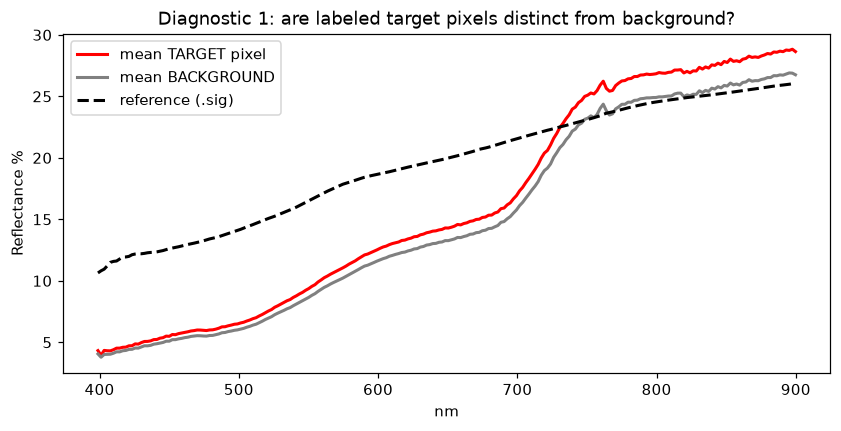

target-vs-background relative difference: 0.076  (small <0.1 => labels likely on background)
fraction of target pixels above bg 95th-pct anomaly: 6.53%  (near 5% => not anomalous => positional error)


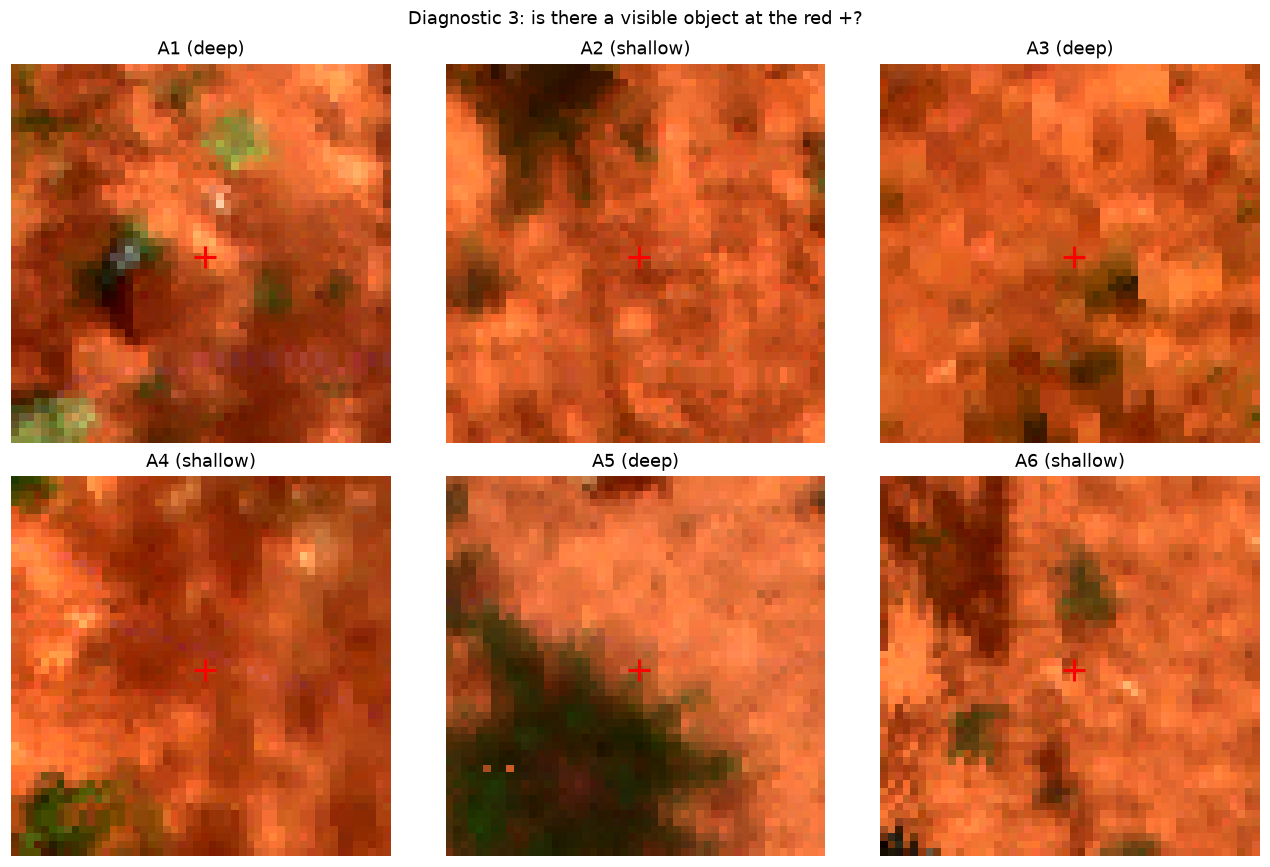

In [9]:
# 1) spectra overlay (percent scale)
tgt_all=np.vstack([t['spectra'] for t in targets if len(t['spectra'])])
mean_tgt=tgt_all.mean(0); mean_bg=to_np(mu)
ref=(ref_nonmetal if ref_nonmetal is not None else ref_metal)[band_ok]
plt.figure(figsize=(9,4))
plt.plot(WL_use, mean_tgt,'r',lw=2,label='mean TARGET pixel')
plt.plot(WL_use, mean_bg,'gray',lw=2,label='mean BACKGROUND')
plt.plot(WL_use, ref,'k--',lw=2,label='reference (.sig)')
plt.xlabel('nm'); plt.ylabel('Reflectance %'); plt.legend()
plt.title('Diagnostic 1: are labeled target pixels distinct from background?'); plt.show()

sep = np.linalg.norm(mean_tgt-mean_bg)/ (np.linalg.norm(mean_bg)+1e-9)
print(f"target-vs-background relative difference: {sep:.3f}  (small <0.1 => labels likely on background)")

# 2) are labeled pixels anomalous? (RX with global bg)
xm_t=to_xp(tgt_all)-mu
rx_t=to_np(xp.einsum('ij,ij->i', xm_t@Ci, xm_t))
bg_sample=field[bg_mask][:,band_ok]
idx=np.random.default_rng(0).choice(bg_sample.shape[0],20000,replace=False)
xm_b=to_xp(bg_sample[idx])-mu
rx_b=to_np(xp.einsum('ij,ij->i', xm_b@Ci, xm_b))
thr95=np.percentile(rx_b,95)
frac=(rx_t>thr95).mean()
print(f"fraction of target pixels above bg 95th-pct anomaly: {frac:.2%}  (near 5% => not anomalous => positional error)")

# 3) zoomed crops
import matplotlib.patches as mpatches
fig,axes=plt.subplots(2,3,figsize=(12,8))
for ax,t in zip(axes.ravel(), targets[:6]):
    r,c=t['r'],t['c']; win=25
    crop=rgb_of(field[max(0,r-win):r+win, max(0,c-win):c+win])
    ax.imshow(crop); ax.plot(min(win,c), min(win,r),'r+',ms=15,mew=2)
    ax.set_title(f"{t['id']} ({t['burial']})"); ax.axis('off')
fig.suptitle('Diagnostic 3: is there a visible object at the red +?'); plt.tight_layout(); plt.show()

### Figure 2 — signature degradation with burial

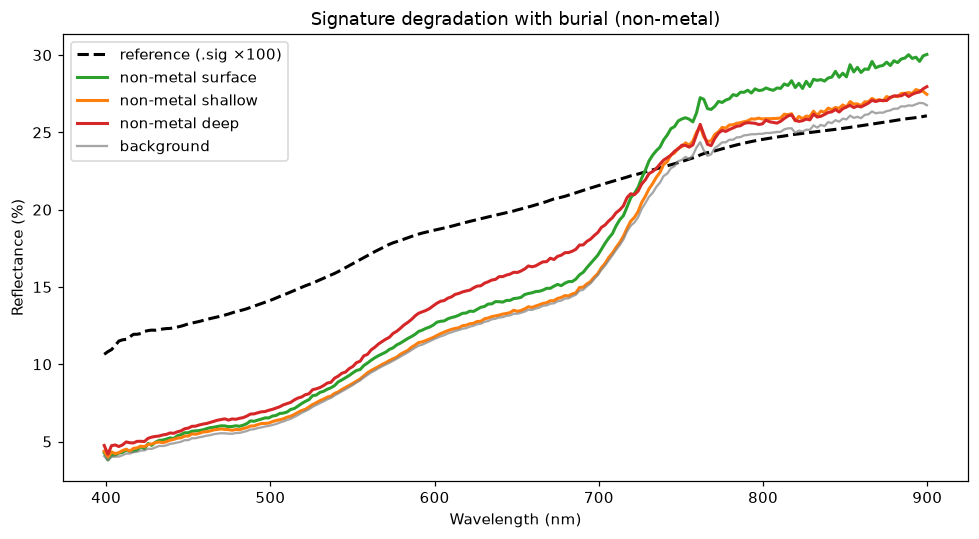

In [10]:
def mean_spec(mat,bur):
    S=[t['spectra'].mean(0) for t in targets if t['material']==mat and t['burial']==bur and len(t['spectra'])]
    return np.mean(S,0) if S else None
plt.figure(figsize=(9,5))
ref=ref_nonmetal if ref_nonmetal is not None else ref_metal
if ref is not None: plt.plot(WL_use, ref[band_ok],'k--',lw=2,label='reference (.sig ×100)')
for b in ['surface','shallow','deep']:
    s=mean_spec('non_metal',b)
    if s is not None: plt.plot(WL_use,s,lw=2,color=colors[b],label=f'non-metal {b}')
plt.plot(WL_use, to_np(mu), color='gray', alpha=.7, label='background')
plt.xlabel('Wavelength (nm)'); plt.ylabel('Reflectance (%)'); plt.legend()
plt.title('Signature degradation with burial (non-metal)'); plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig2_degradation.png",bbox_inches='tight'); plt.show()

burial      n tgt-vs-bg diff  % anomalous
surface    31          0.085        9.0%
shallow    70          0.068        6.0%
deep       30          0.090        5.2%


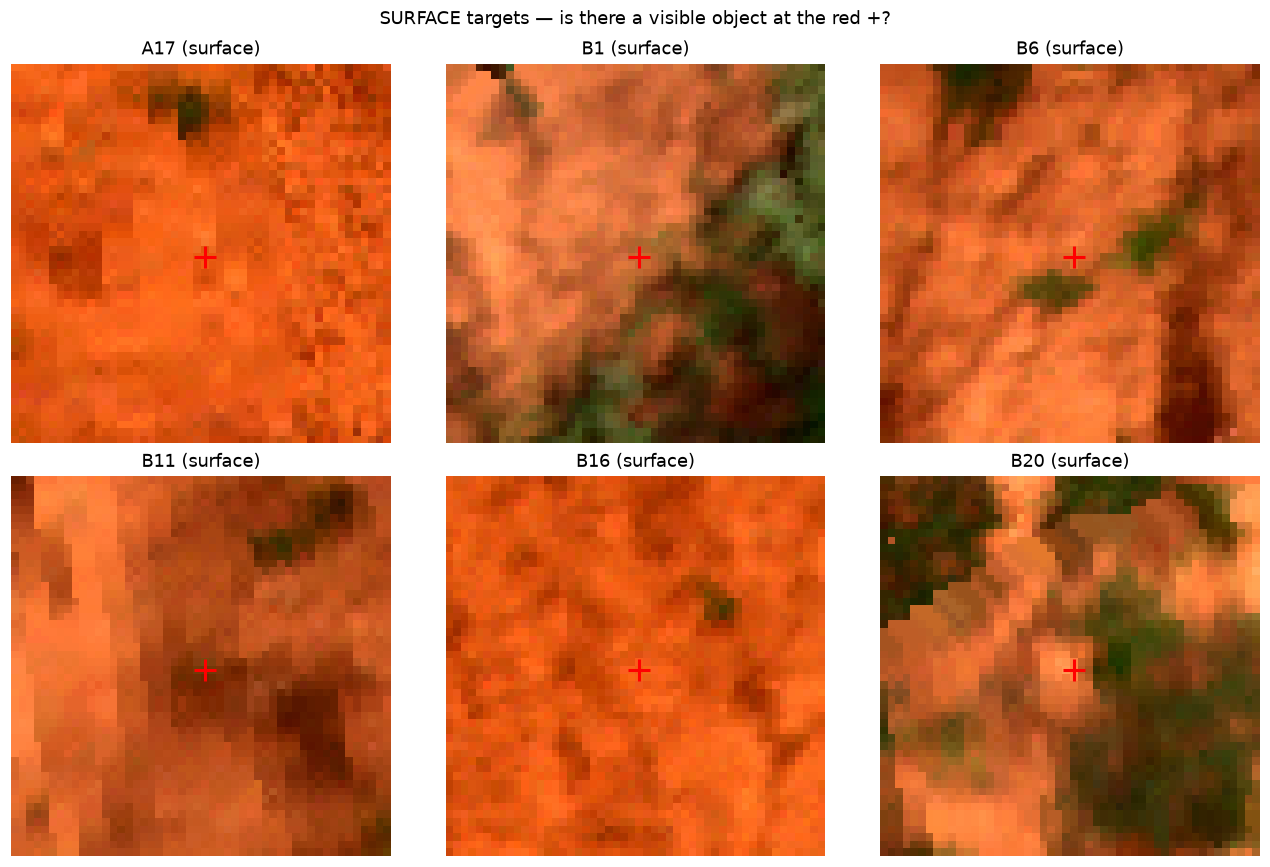

In [11]:
## 8c · DIAGNOSTIC by burial state — the question that actually matters
thr95 = np.percentile(rx_b, 95)   # rx_b from cell 8b (background anomaly)

print(f"{'burial':8s} {'n':>4s} {'tgt-vs-bg diff':>14s} {'% anomalous':>12s}")
for b in ['surface','shallow','deep']:
    grp=[t for t in targets if t['burial']==b and len(t['spectra'])]
    if not grp: continue
    tg=np.vstack([t['spectra'] for t in grp])
    diff=np.linalg.norm(tg.mean(0)-to_np(mu))/(np.linalg.norm(to_np(mu))+1e-9)
    xm=to_xp(tg)-mu
    rxg=to_np(xp.einsum('ij,ij->i', xm@Ci, xm))
    frac=(rxg>thr95).mean()
    print(f"{b:8s} {len(grp):4d} {diff:14.3f} {frac:11.1%}")

# show crops of SURFACE targets specifically (the ones that CAN be visible)
surf=[t for t in targets if t['burial']=='surface'][:6]
fig,axes=plt.subplots(2,3,figsize=(12,8))
for ax,t in zip(axes.ravel(), surf):
    r,c=t['r'],t['c']; win=25
    crop=rgb_of(field[max(0,r-win):r+win, max(0,c-win):c+win])
    ax.imshow(crop); ax.plot(min(win,c),min(win,r),'r+',ms=15,mew=2)
    ax.set_title(f"{t['id']} (surface)"); ax.axis('off')
fig.suptitle('SURFACE targets — is there a visible object at the red +?'); plt.tight_layout(); plt.show()

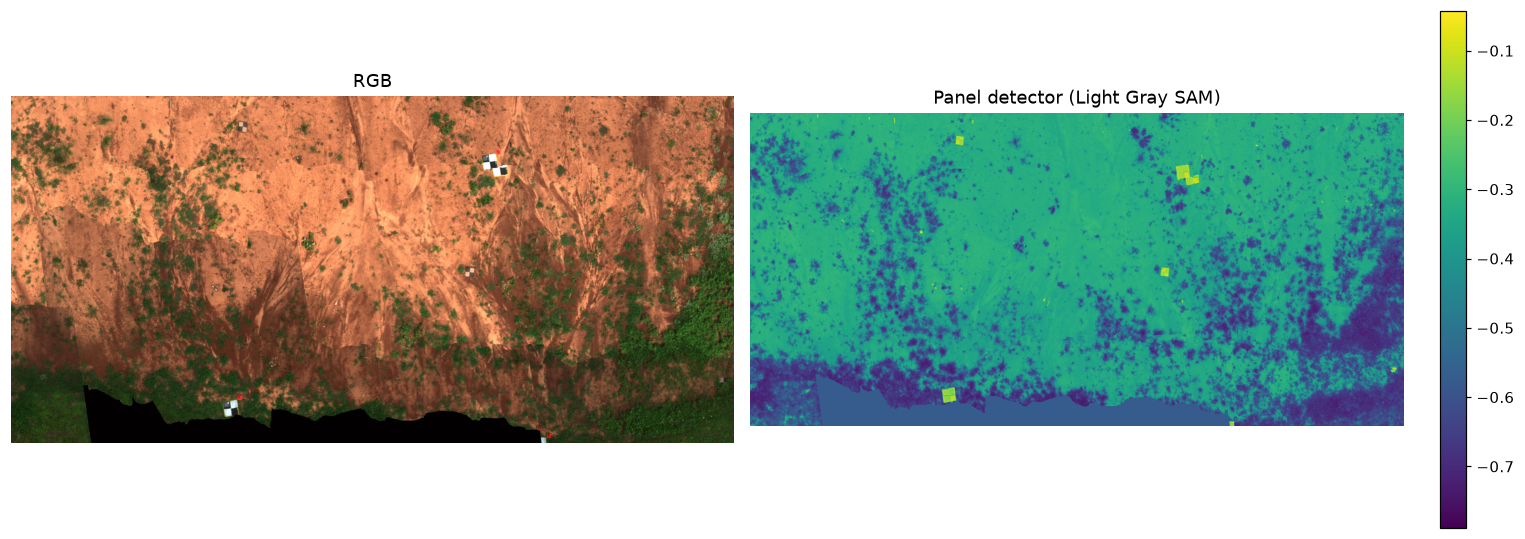

If bright blobs land on the visible checkerboard panels -> detection pipeline WORKS.


In [12]:
## 8e · POSITIVE CONTROL — does the pipeline detect the calibration panels?
panels = pd.read_csv(PANEL_CSV, encoding='utf-8-sig')
panels.columns = [c.strip() for c in panels.columns]
pl_ref = np.interp(WL, panels['Wavelength'].values,
                   panels['Light Gray'].values)[band_ok].astype(np.float32)
Xraw = field[:, :, band_ok].reshape(-1, int(band_ok.sum()))
def sam_np(X, t):
    return -np.arccos(np.clip((X@t)/(np.linalg.norm(X,axis=1)*np.linalg.norm(t)+1e-12), -1, 1))
panel_map = sam_np(Xraw, pl_ref).reshape(H, W)
fig,(a1,a2)=plt.subplots(1,2,figsize=(14,5))
a1.imshow(RGB); a1.set_title('RGB'); a1.axis('off')
im=a2.imshow(panel_map, cmap='viridis'); a2.set_title('Panel detector (Light Gray SAM)')
a2.axis('off'); plt.colorbar(im,ax=a2,fraction=0.046); plt.tight_layout(); plt.show()
print("If bright blobs land on the visible checkerboard panels -> detection pipeline WORKS.")

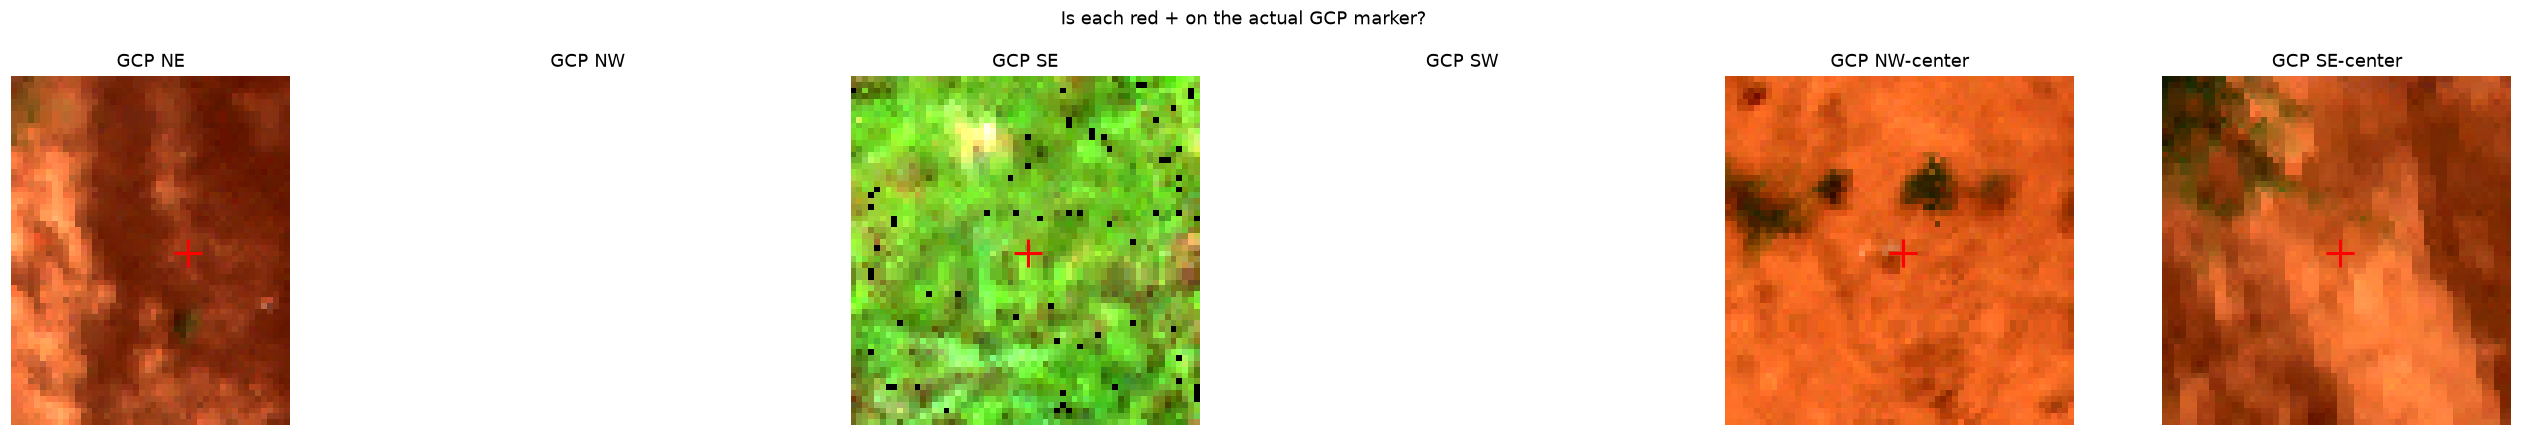

In [13]:
## 8f · Georeferencing check via GCPs
gcp = pd.read_csv(os.path.join(DATA_DIR,"GCP_points.csv"), encoding='utf-8-sig')
gcp.columns=[c.strip() for c in gcp.columns]
fig,axes=plt.subplots(1,len(gcp),figsize=(4*len(gcp),4))
for ax,(_,g) in zip(np.atleast_1d(axes), gcp.iterrows()):
    row,col=lonlat_to_pixel(float(g['Longitude']),float(g['Latitude']))
    r,c=int(round(row))-r0,int(round(col))-c0; win=30
    if 0<=r<H and 0<=c<W:
        ax.imshow(rgb_of(field[max(0,r-win):r+win,max(0,c-win):c+win]))
        ax.plot(min(win,c),min(win,r),'r+',ms=18,mew=2)
    ax.set_title(str(g['Name'])); ax.axis('off')
plt.suptitle('Is each red + on the actual GCP marker?'); plt.tight_layout(); plt.show()

surface targets tested: 17
median marker->object offset (dr,dc): (-1, 4)
offset scatter (std): dr=11.0px dc=10.8px
mean match gain from searching: 0.092

INTERPRET:
  small std (<~5px) + positive gain  => SYSTEMATIC SHIFT: apply the median offset (next cell)
  large scatter + ~0 gain            => objects not optically distinct => limitation study


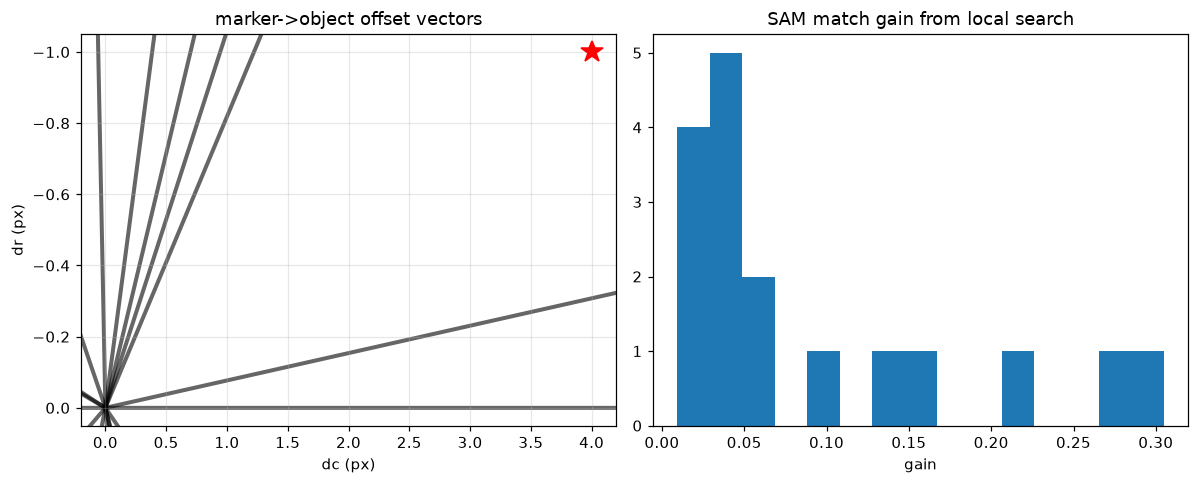

In [14]:
## 8g · DECISIVE TEST — is there a consistent georeferencing offset on surface targets?
from scipy.ndimage import uniform_filter
SEARCH_PX = 20   # how far to look for the real object around each recorded marker

def sam_np(X, t):
    return -np.arccos(np.clip((X@t)/(np.linalg.norm(X,axis=1)*np.linalg.norm(t)+1e-12), -1, 1))

surf = [t for t in targets if t['burial']=='surface' and t.get('sig')]
offs, gains = [], []
for t in surf:
    ref = read_sig(t['sig'])[band_ok].astype(np.float32)     # SAM is scale-invariant
    r,c = t['r'], t['c']
    r0s,r1s = max(0,r-SEARCH_PX), min(H,r+SEARCH_PX+1)
    c0s,c1s = max(0,c-SEARCH_PX), min(W,c+SEARCH_PX+1)
    sub = field[r0s:r1s, c0s:c1s][:,:,band_ok].reshape(-1, int(band_ok.sum()))
    sc  = sam_np(sub, ref).reshape(r1s-r0s, c1s-c0s)
    pr,pc = np.unravel_index(np.argmax(sc), sc.shape)
    offs.append((r0s+pr - r, c0s+pc - c))
    at_marker = sam_np(field[r,c][band_ok][None], ref)[0]
    gains.append(float(sc.max() - at_marker))
offs = np.array(offs); gains = np.array(gains)

med = (int(np.median(offs[:,0])), int(np.median(offs[:,1])))
print(f"surface targets tested: {len(surf)}")
print(f"median marker->object offset (dr,dc): {med}")
print(f"offset scatter (std): dr={offs[:,0].std():.1f}px dc={offs[:,1].std():.1f}px")
print(f"mean match gain from searching: {gains.mean():.3f}")
print("\nINTERPRET:")
print("  small std (<~5px) + positive gain  => SYSTEMATIC SHIFT: apply the median offset (next cell)")
print("  large scatter + ~0 gain            => objects not optically distinct => limitation study")

fig,(a1,a2)=plt.subplots(1,2,figsize=(11,4.5))
a1.quiver(np.zeros(len(offs)), np.zeros(len(offs)), offs[:,1], offs[:,0],
          angles='xy', scale_units='xy', scale=1, alpha=0.6)
a1.plot(med[1], med[0], 'r*', ms=15); a1.set_title('marker->object offset vectors')
a1.set_xlabel('dc (px)'); a1.set_ylabel('dr (px)'); a1.grid(alpha=.3); a1.invert_yaxis()
a2.hist(gains, bins=15); a2.set_title('SAM match gain from local search'); a2.set_xlabel('gain')
plt.tight_layout(); plt.show()

## 9 · FIXED detection — local background + object-level evaluation

Two changes that address the random results:

* **Local-background high-pass:** subtract a local mean (boxcar) per band before detection. This
  removes soil/illumination trends so targets stand out against their *immediate* surroundings
  instead of one global average — essential in a heterogeneous field.
* **Larger, GSD-aware target windows** (`TARGET_HALF_PX`) so a window actually covers an object.
* **Object-level Pd/FAR with a tolerance radius** (`TOL_PX`): a target counts as detected if a
  score peak appears within `TOL_PX` of its recorded location. This tolerates GPS/survey positional
  error (the likely cause of the random pixel-level numbers) and is the standard demining metric.

Tune `BOX_PX`, `TARGET_HALF_PX`, `TOL_PX` to your GSD (≈9 mm/px ⇒ a 12 cm mine ≈ 13 px).

In [15]:
from scipy.ndimage import uniform_filter, maximum_filter

BOX_PX         = 31    # local-background boxcar (should be several x object size)
TARGET_HALF_PX = 5     # half-window counted as target (object ~10-30 px across)
TOL_PX         = 12    # object-level detection tolerance (positional error budget)

# rebuild target masks at the larger size + recompute target/background pixels
def tmask(t,half=TARGET_HALF_PX):
    m=np.zeros((H,W),bool)
    m[max(0,t['r']-half):t['r']+half+1, max(0,t['c']-half):t['c']+half+1]=True; return m
all_t=np.zeros((H,W),bool)
for t in targets: t['mask']=tmask(t); all_t|=t['mask']

# ---- local-background high-pass (removes soil/illumination trend) ----
t0=time.time()
HP=np.empty_like(field)
for b in range(field.shape[2]):
    HP[:,:,b]=field[:,:,b]-uniform_filter(field[:,:,b],size=BOX_PX,mode='reflect')
print(f"high-pass in {time.time()-t0:.1f}s")

band_idx=np.where(band_ok)[0]
HPb=HP[:,:,band_ok]
Xhp=HPb.reshape(-1,int(band_ok.sum()))

# background stats on high-passed data
bg_mask2=~binary_dilation(all_t,iterations=8)
BGhp=Xhp[bg_mask2.ravel()]
rng=np.random.default_rng(0)
if BGhp.shape[0]>200000: BGhp=BGhp[rng.choice(BGhp.shape[0],200000,replace=False)]
mu_h=to_xp(BGhp.mean(0)); C_h=xp.cov(to_xp(BGhp).T)+COV_REG*xp.eye(int(band_ok.sum())); Ci_h=xp.linalg.inv(C_h)

# target reference, high-passed the same way is not meaningful (ref has no local bg);
# use the mean high-passed TARGET signature as the matched template (data-driven, robust)
tmpl=to_xp(Xhp[all_t.ravel()].mean(0).astype(np.float32))

def score_maps(Xhp, tmpl, mu, Ci, batch=400_000):
    d=tmpl-mu; Cid=Ci@d; k=float(d@Cid); tn=float(xp.linalg.norm(tmpl))
    N=Xhp.shape[0]; out={'ACE':np.empty(N,np.float32),'MF':np.empty(N,np.float32),'SAM':np.empty(N,np.float32)}
    for s in range(0,N,batch):
        e=min(N,s+batch); Xb=to_xp(Xhp[s:e]); xm=Xb-mu
        proj=xm@Cid; quad=xp.einsum('ij,ij->i',xm@Ci,xm)
        out['ACE'][s:e]=to_np(proj**2/(quad*k+1e-12))
        out['MF'][s:e]=to_np(proj/(k+1e-12))
        out['SAM'][s:e]=to_np(-xp.arccos(xp.clip((Xb@tmpl)/(xp.linalg.norm(Xb,axis=1)*tn+1e-12),-1,1)))
        if gpu_ok: cp.get_default_memory_pool().free_all_blocks()
    return {kk:v.reshape(H,W) for kk,v in out.items()}

t0=time.time(); SM=score_maps(Xhp,tmpl,mu_h,Ci_h); print(f"score maps in {time.time()-t0:.1f}s")

def object_pd_far(smap, centers, tol=TOL_PX, n=60):
    peaks=(smap==maximum_filter(smap,size=3))
    ys,xs=np.where(peaks); pv=smap[ys,xs]
    o=np.argsort(-pv); ys,xs,pv=ys[o],xs[o],pv[o]
    cen=np.array([[t['r'],t['c']] for t in centers]); area=smap.size
    thr=np.linspace(pv.min(),pv.max(),n); Pd=[];FAR=[]
    for th in thr:
        m=pv>=th; det=set(); fa=0
        for yy,xx in zip(ys[m],xs[m]):
            dd=np.hypot(cen[:,0]-yy,cen[:,1]-xx); j=int(np.argmin(dd))
            if dd[j]<=tol: det.add(j)
            else: fa+=1
        Pd.append(len(det)/len(centers)); FAR.append(fa/area)
    return np.array(FAR),np.array(Pd)

def pd_at(far,pdv,tf):
    i=np.argsort(far); return float(np.interp(tf,far[i],pdv[i]))

print("\nObject-level detection (all targets):")
for det in ['ACE','MF','SAM']:
    far,pdv=object_pd_far(SM[det], targets)
    print(f"  {det}: maxPd={pdv.max():.2f}  Pd@FAR1e-3={pd_at(far,pdv,1e-3):.2f}  Pd@FAR1e-2={pd_at(far,pdv,1e-2):.2f}")

high-pass in 102.9s
score maps in 6.8s

Object-level detection (all targets):
  ACE: maxPd=1.00  Pd@FAR1e-3=0.25  Pd@FAR1e-2=0.93
  MF: maxPd=1.00  Pd@FAR1e-3=0.30  Pd@FAR1e-2=0.93
  SAM: maxPd=1.00  Pd@FAR1e-3=0.19  Pd@FAR1e-2=0.69


## 8f · Per-target HSI score + continuous depth analysis

Stores a real per-target detection score (peak ACE score within the detection tolerance),
then analyses detectability against **measured depth in cm** directly — no arbitrary depth
bins. Also saves `hsi_per_target_scores.csv`.

per-target HSI scores stored: 131/131  (detector=ACE)
detection threshold (95th pct of background): 0.0810

CONTINUOUS depth vs HSI score:
  Pearson  r=0.065 (p=0.459)
  Spearman r=-0.003 (p=0.969)
  linear slope = 0.0002 score-units per cm


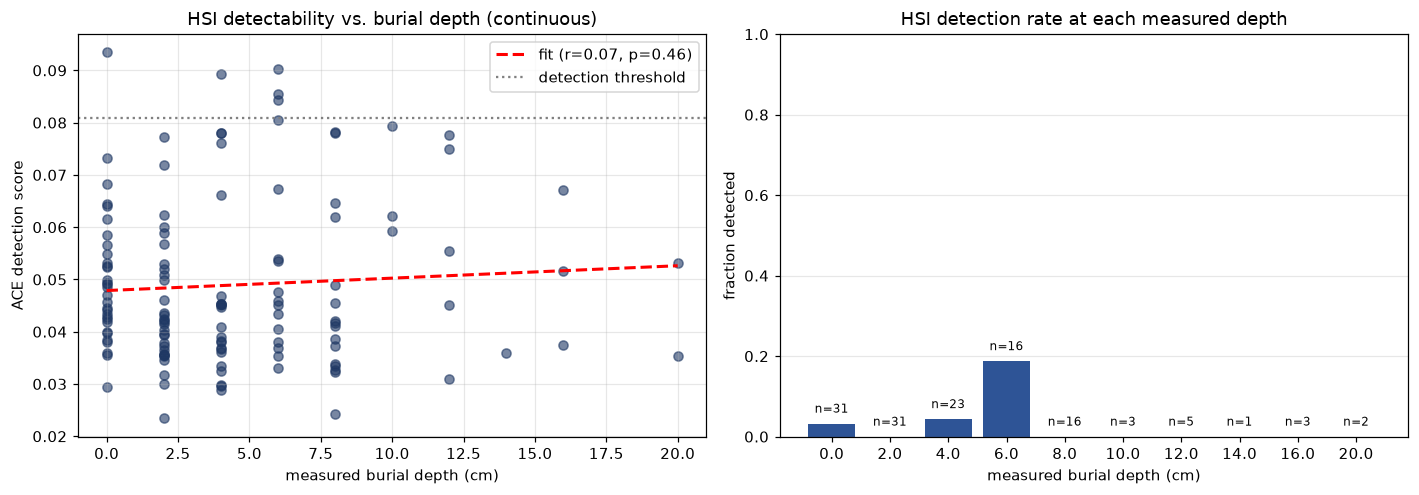


saved hsi_depth_continuous.png and hsi_per_target_scores.csv
=> upload hsi_per_target_scores.csv and I can rebuild the report on real continuous data.


In [16]:
import pandas as pd   # re-bind: 'pd' may have been overwritten earlier
# ============================================================================
#  PER-TARGET HSI SCORE + CONTINUOUS DEPTH ANALYSIS  (Path A)
#  Add this AFTER the detection cell that builds `SM` (the ACE/MF/SAM score maps).
#  It stores a REAL per-target detection score, saves it to CSV, and makes the
#  continuous depth-vs-detection figure that replaces the arbitrary depth bins.
# ============================================================================
from scipy.stats import pearsonr, spearmanr

# --- 1. real per-target score: peak ACE score within the detection tolerance ---
def peak_near(smap, r, c, tol=TOL_PX):
    r0,r1=max(0,r-tol),min(H,r+tol+1); c0,c1=max(0,c-tol),min(W,c+tol+1)
    sub=smap[r0:r1, c0:c1]
    return float(sub.max()) if sub.size else np.nan

DETECTOR='ACE'                       # ACE was the strongest in your Pd/FAR results
for t in targets:
    t['hsi_score']=peak_near(SM[DETECTOR], t['r'], t['c'])

# background reference: peak scores at random NON-target locations (same tolerance window)
rng=np.random.default_rng(0)
bg_scores=[]
for _ in range(500):
    r=rng.integers(TOL_PX, H-TOL_PX); c=rng.integers(TOL_PX, W-TOL_PX)
    if not all_t[r,c]:
        bg_scores.append(peak_near(SM[DETECTOR], r, c))
bg_scores=np.array(bg_scores)
hsi_thr=np.nanpercentile(bg_scores, 95)          # 95th-pct background = detection threshold
for t in targets:
    t['hsi_detected']=bool(np.isfinite(t['hsi_score']) and t['hsi_score']>hsi_thr)

n_scored=sum(np.isfinite(t['hsi_score']) for t in targets)
print(f"per-target HSI scores stored: {n_scored}/{len(targets)}  (detector={DETECTOR})")
print(f"detection threshold (95th pct of background): {hsi_thr:.4f}")

# --- 2. CONTINUOUS depth analysis (no arbitrary bins) ---
dd=pd.DataFrame([dict(depth_cm=t['depth_cm'], score=t['hsi_score'],
                      detected=t['hsi_detected'], material=t.get('material'))
                 for t in targets]).dropna(subset=['depth_cm','score'])

r_p,p_p=pearsonr(dd['depth_cm'], dd['score'])
r_s,p_s=spearmanr(dd['depth_cm'], dd['score'])
z=np.polyfit(dd['depth_cm'], dd['score'], 1)
print(f"\nCONTINUOUS depth vs HSI score:")
print(f"  Pearson  r={r_p:.3f} (p={p_p:.3g})")
print(f"  Spearman r={r_s:.3f} (p={p_s:.3g})")
print(f"  linear slope = {z[0]:.4f} score-units per cm")

# --- 3. the figure: score vs depth, with fit; plus detection rate at each real depth ---
fig,ax=plt.subplots(1,2,figsize=(13,4.6))
# left: continuous scatter + fit
ax[0].scatter(dd['depth_cm'], dd['score'], alpha=0.6, color='#1f3864')
xs=np.linspace(0, dd['depth_cm'].max(), 50)
ax[0].plot(xs, np.polyval(z,xs), 'r--', lw=2, label=f'fit (r={r_p:.2f}, p={p_p:.2g})')
ax[0].axhline(hsi_thr, color='gray', ls=':', label='detection threshold')
ax[0].set_xlabel('measured burial depth (cm)'); ax[0].set_ylabel(f'{DETECTOR} detection score')
ax[0].set_title('HSI detectability vs. burial depth (continuous)'); ax[0].legend(); ax[0].grid(alpha=.3)
# right: detection rate at each ACTUAL measured depth (honest, no binning)
by_depth=dd.groupby('depth_cm')['detected'].agg(['mean','count'])
ax[1].bar(by_depth.index.astype(str), by_depth['mean'], color='#2E5496')
for x,(m,n) in enumerate(zip(by_depth['mean'],by_depth['count'])):
    ax[1].text(x, m+0.02, f'n={n}', ha='center', va='bottom', fontsize=8)
ax[1].set_xlabel('measured burial depth (cm)'); ax[1].set_ylabel('fraction detected')
ax[1].set_title('HSI detection rate at each measured depth'); ax[1].set_ylim(0,1); ax[1].grid(axis='y',alpha=.3)
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR,'hsi_depth_continuous.png'),dpi=150,bbox_inches='tight'); plt.show()

# --- 4. save per-target scores so the report can be rebuilt from real data ---
dd_full=pd.DataFrame([dict(id=t['id'], depth_cm=t['depth_cm'],
                           surface=(t['depth_cm']==0), material=t.get('material'),
                           hsi_score=t['hsi_score'], hsi_detected=t['hsi_detected'])
                      for t in targets])
dd_full.to_csv(os.path.join(FIG_DIR,'hsi_per_target_scores.csv'), index=False)
print(f"\nsaved hsi_depth_continuous.png and hsi_per_target_scores.csv")
print("=> upload hsi_per_target_scores.csv and I can rebuild the report on real continuous data.")


## 10 · Results — Pd vs FAR by burial state (the headline)

Object-level detection curves per burial depth. A good detector reaches high Pd at low FAR; the
curve should sit lower for deeper targets — that gradient **is** your research finding.

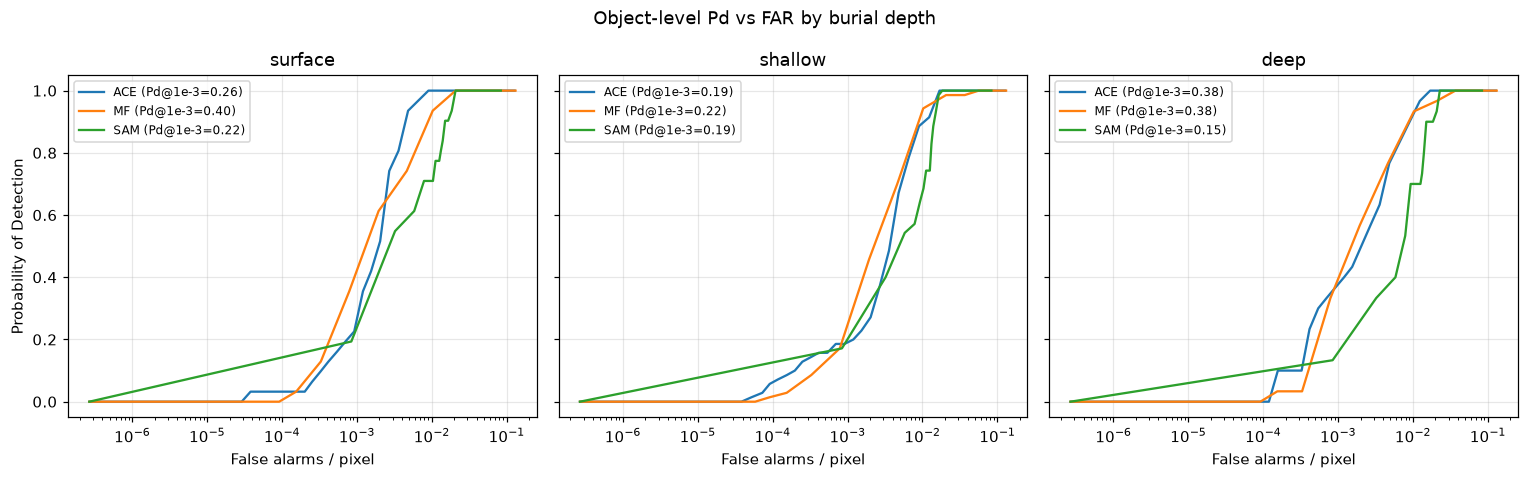

,detector,burial,maxPd,Pd_at_FAR_1e3,Pd_at_FAR_1e2,n
0,ACE,surface,1.0,0.261,1.000,31
1,MF,surface,1.0,0.401,0.925,31
2,SAM,surface,1.0,0.217,0.710,31
3,ACE,shallow,1.0,0.190,0.894,70
4,MF,shallow,1.0,0.224,0.932,70
5,SAM,shallow,1.0,0.187,0.672,70
6,ACE,deep,1.0,0.376,0.919,30
7,MF,deep,1.0,0.375,0.924,30
8,SAM,deep,1.0,0.146,0.700,30


In [17]:
fig,ax=plt.subplots(1,3,figsize=(14,4.4),sharey=True)
rows=[]
for a,b in zip(ax,['surface','shallow','deep']):
    grp=[t for t in targets if t['burial']==b]
    if not grp: a.set_title(f'{b} (n=0)'); continue
    for det in ['ACE','MF','SAM']:
        far,pdv=object_pd_far(SM[det], grp)
        a.plot(far,pdv,label=f"{det} (Pd@1e-3={pd_at(far,pdv,1e-3):.2f})")
        rows.append(dict(detector=det,burial=b,maxPd=pdv.max(),
                         Pd_at_FAR_1e3=pd_at(far,pdv,1e-3),Pd_at_FAR_1e2=pd_at(far,pdv,1e-2),n=len(grp)))
    a.set_xscale('log'); a.set_xlabel('False alarms / pixel'); a.set_title(b); a.grid(alpha=.3); a.legend(fontsize=8)
ax[0].set_ylabel('Probability of Detection')
fig.suptitle('Object-level Pd vs FAR by burial depth'); plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig3_pd_far_by_burial.png",bbox_inches='tight'); plt.show()

import pandas as pd
results=pd.DataFrame(rows); results.to_csv(f"{FIG_DIR}/results_object_level.csv",index=False)
results.round(3)

## 11 · Detection score map overlay (sanity check)

The ACE score map with recorded target locations. Bright blobs at/near the red markers = working
detection. If blobs are consistently *offset* from markers, increase `TOL_PX` (positional error).

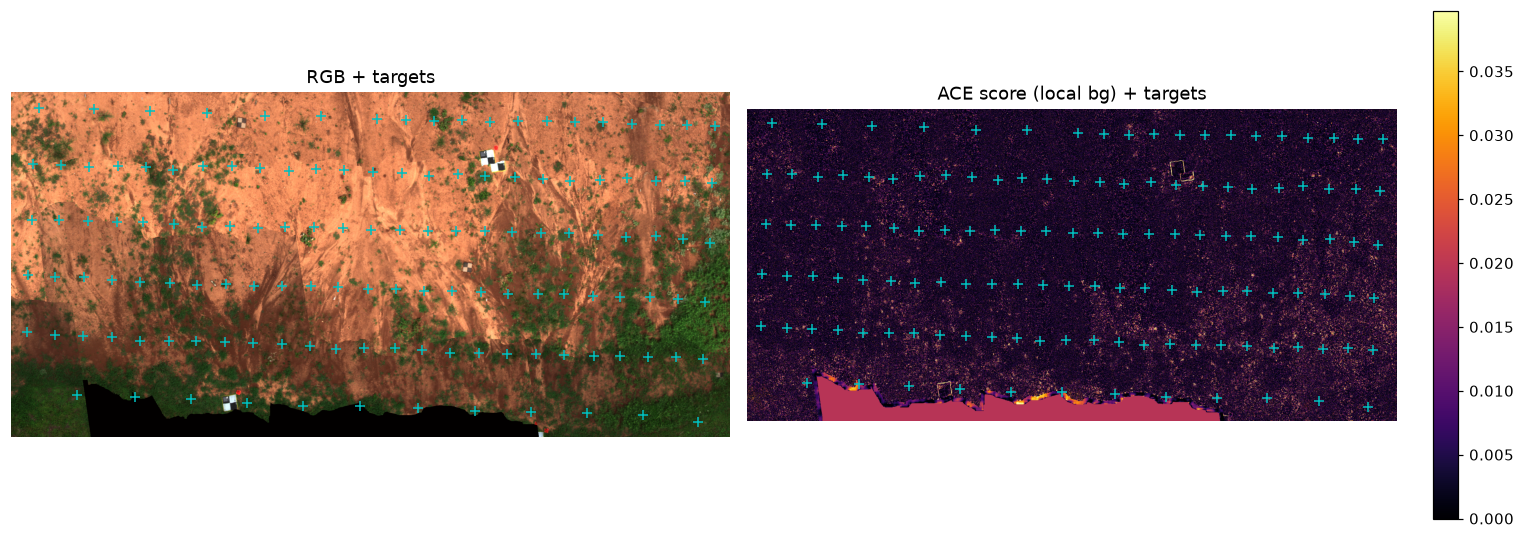

In [18]:
ace_map=SM['ACE']
fig,(a1,a2)=plt.subplots(1,2,figsize=(14,5))
a1.imshow(RGB); a1.set_title('RGB + targets'); a1.axis('off')
for t in targets: a1.plot(t['c'],t['r'],'c+',ms=6,mew=1)
im=a2.imshow(np.clip(ace_map,0,np.percentile(ace_map,99.5)),cmap='inferno')
for t in targets: a2.plot(t['c'],t['r'],'c+',ms=6,mew=1)
a2.set_title('ACE score (local bg) + targets'); a2.axis('off')
plt.colorbar(im,ax=a2,fraction=0.046); plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig4_score_overlay.png",bbox_inches='tight'); plt.show()

## 12 · Notes
* **GPU OOM?** If `Xall` doesn't fit 8 GB, run detectors in row-tiles: loop over slices of
  `field[:, :, band_ok]`, move each slice to GPU, score, move back. The math is unchanged.
* **`.sig` matching:** filenames start with the target ID (e.g. `A4_...`), so `match_sig` keys on
  that. Print `[t['id'] for t in targets if not t['sig']]` to see any misses.
* **Depth as continuous:** beyond 3 bins, regress AP / Fisher ratio against raw `Depth (cm)`.
* **Reproduce first:** confirm surface non-metal ACE looks sane before trusting deep results.
* Verify the dataset license before publishing.


## 12 · Publication graphs — HSI depth analysis

Clean, paper-ready summary figures: the depth gradient as bins **and** as a continuous
regression (the continuous version avoids the arbitrary 6 cm threshold and is the stronger result).

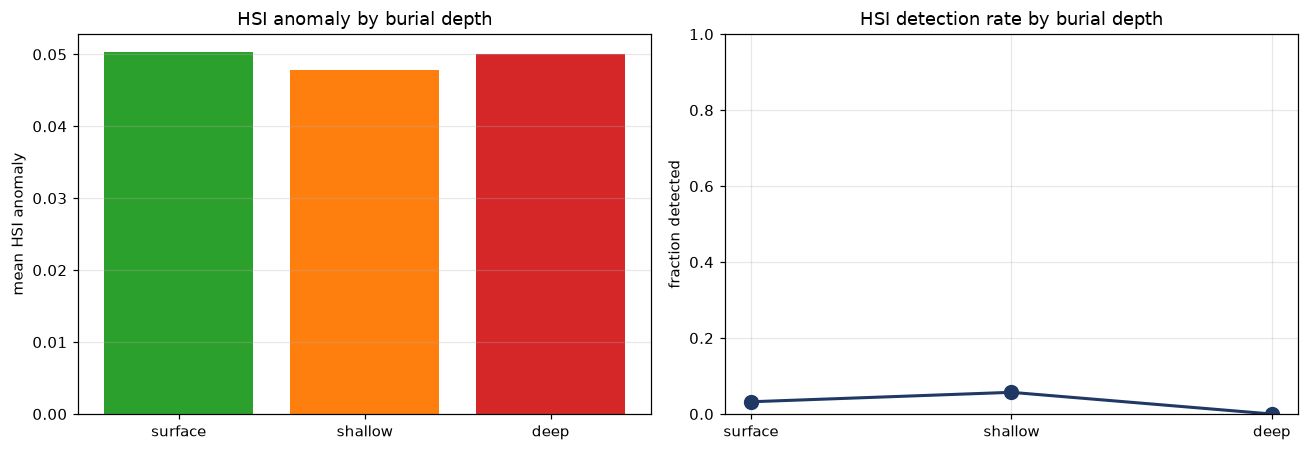

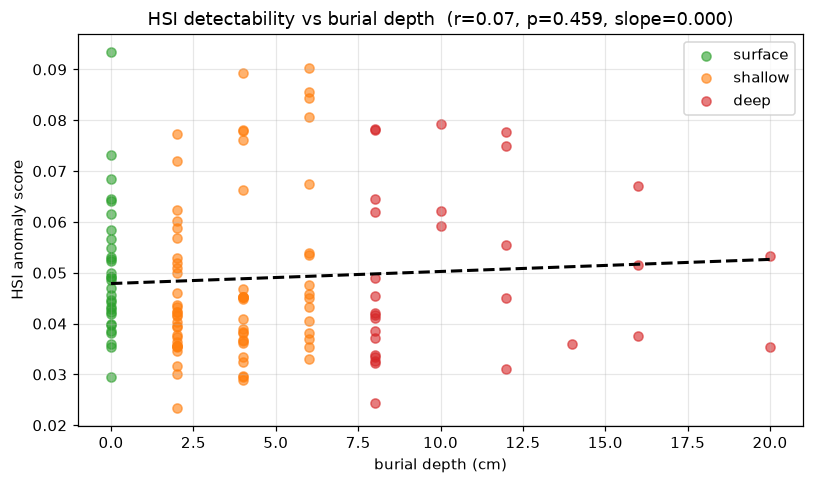

continuous depth fit: r=0.065, p=0.459, slope=0.0002


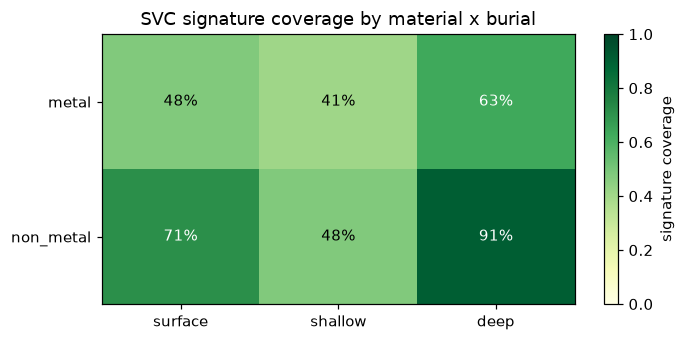

saved: paper_hsi_by_burial.png, paper_hsi_depth_continuous.png, paper_sig_coverage.png


In [19]:
from scipy.stats import pearsonr
order=['surface','shallow','deep']; colors={'surface':'#2ca02c','shallow':'#ff7f0e','deep':'#d62728'}

# assemble per-target HSI score if not already present
if not any('hsi_score' in t for t in targets):
    # fall back to the by-burial anomaly numbers already computed; skip if unavailable
    pass
hdf=pd.DataFrame([dict(id=t['id'], burial=t['burial'], depth_cm=t.get('depth_cm',np.nan),
                       material=t.get('material'), hsi=t.get('hsi_score',np.nan)) for t in targets])

# ---- Figure A: HSI anomaly + detection rate by burial ----
fig,ax=plt.subplots(1,2,figsize=(12,4.2))
mean_by=hdf.groupby('burial')['hsi'].mean().reindex(order)
ax[0].bar(order,[mean_by[b] for b in order],color=[colors[b] for b in order])
ax[0].set_ylabel('mean HSI anomaly'); ax[0].set_title('HSI anomaly by burial depth'); ax[0].grid(axis='y',alpha=.3)
# detection rate uses the background 95th-pct threshold if available
_thr=globals().get('hsi_thr', np.nanpercentile(hdf['hsi'].dropna(),75))
det=hdf.groupby('burial').apply(lambda d:(d['hsi']>_thr).mean()).reindex(order)
ax[1].plot(order,[det[b] for b in order],'o-',lw=2,color='#1f3864',ms=9)
ax[1].set_ylabel('fraction detected'); ax[1].set_title('HSI detection rate by burial depth'); ax[1].grid(alpha=.3); ax[1].set_ylim(0,1)
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR,'paper_hsi_by_burial.png'),dpi=150,bbox_inches='tight'); plt.show()

# ---- Figure B: continuous depth regression (no arbitrary bins) ----
dd=hdf.dropna(subset=['depth_cm','hsi'])
if len(dd)>2:
    fig,ax=plt.subplots(figsize=(7.5,4.5))
    for b in order:
        s=dd[dd.burial==b]; ax.scatter(s['depth_cm'],s['hsi'],alpha=0.6,color=colors[b],label=b)
    z=np.polyfit(dd['depth_cm'],dd['hsi'],1); xs=np.linspace(0,dd['depth_cm'].max(),50)
    ax.plot(xs,np.polyval(z,xs),'k--',lw=2)
    r,p=pearsonr(dd['depth_cm'],dd['hsi'])
    ax.set_xlabel('burial depth (cm)'); ax.set_ylabel('HSI anomaly score')
    ax.set_title(f'HSI detectability vs burial depth  (r={r:.2f}, p={p:.3g}, slope={z[0]:.3f})')
    ax.legend(); ax.grid(alpha=.3)
    plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR,'paper_hsi_depth_continuous.png'),dpi=150,bbox_inches='tight'); plt.show()
    print(f"continuous depth fit: r={r:.3f}, p={p:.3g}, slope={z[0]:.4f}")

# ---- Figure C: signature coverage heatmap (material x burial) ----
sc=pd.DataFrame([dict(material=t.get('material'),burial=t['burial'],has=bool(t.get('sig'))) for t in targets])
piv=sc.groupby(['material','burial'])['has'].mean().unstack().reindex(columns=order)
fig,ax=plt.subplots(figsize=(6.5,3.2))
im=ax.imshow(piv.values,cmap='YlGn',vmin=0,vmax=1,aspect='auto')
ax.set_xticks(range(len(order))); ax.set_xticklabels(order)
ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v=piv.values[i,j]
        if np.isfinite(v): ax.text(j,i,f'{v*100:.0f}%',ha='center',va='center',
                                   color='black' if v<0.6 else 'white',fontsize=10)
plt.colorbar(im,label='signature coverage'); ax.set_title('SVC signature coverage by material x burial')
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR,'paper_sig_coverage.png'),dpi=150,bbox_inches='tight'); plt.show()
print("saved: paper_hsi_by_burial.png, paper_hsi_depth_continuous.png, paper_sig_coverage.png")

## 13 · Save all results & figures to a results folder

Copies every figure and writes the key result tables to `DATA_DIR/results_YYYYMMDD_HHMM/`
so you have one clean folder to pull from for the paper.

In [20]:
import shutil, datetime, json
RESULTS_DIR=os.path.join(DATA_DIR, "results_"+datetime.datetime.now().strftime("%Y%m%d_%H%M"))
os.makedirs(RESULTS_DIR, exist_ok=True)

# 1) copy every PNG already saved in FIG_DIR
n_fig=0
for f in glob.glob(os.path.join(FIG_DIR,"*.png")):
    shutil.copy(f, RESULTS_DIR); n_fig+=1

# 2) target roster + per-target HSI scores
pd.DataFrame([dict(id=t['id'], item=t.get('item'), burial=t['burial'],
                   depth_cm=t.get('depth_cm'), material=t.get('material'),
                   emi_class=t.get('emi_class'), has_sig=bool(t.get('sig')),
                   hsi_score=t.get('hsi_score')) for t in targets]
            ).to_csv(os.path.join(RESULTS_DIR,'targets_full.csv'), index=False)

# 3) summary numbers as JSON (counts, coverage, depth fit)
from collections import Counter
summary=dict(
    n_targets=len(targets),
    n_control_holes=len(holes) if 'holes' in globals() else None,
    burial=dict(Counter(t['burial'] for t in targets)),
    material=dict(Counter(t.get('material') for t in targets)),
    emi_class=dict(Counter(t.get('emi_class') for t in targets)),
    sig_coverage=f"{sum(1 for t in targets if t.get('sig'))}/{len(targets)}",
)
with open(os.path.join(RESULTS_DIR,'summary.json'),'w') as fp: json.dump(summary,fp,indent=2)

print(f"Saved {n_fig} figures + targets_full.csv + summary.json to:")
print(" ", RESULTS_DIR)
print("\nsummary:", json.dumps(summary, indent=2))

Saved 8 figures + targets_full.csv + summary.json to:
  D:/landmine_hsi\results_20260805_0719

summary: {
  "n_targets": 131,
  "n_control_holes": 8,
  "burial": {
    "deep": 30,
    "shallow": 70,
    "surface": 31
  },
  "material": {
    "non_metal": 41,
    "metal": 86,
    "null": 4
  },
  "emi_class": {
    "conductive": 104,
    "inert": 25,
    "unknown": 2
  },
  "sig_coverage": "69/131"
}
